In [1]:
using OrdinaryDiffEq, CairoMakie, Lux

![cat](cat/cat.jpg)

# Physics-informed neural networks
Another variant of hybrid models are physics-informed neural networks (PINNs). In a PINN, neural networks are used to learn both the physical parameters of a system, as well as the solution to the system itself. 

A common example for PINNs, is the damped harmonic oscillator system: 

$$ \frac{\mathrm{d}^2 x}{\mathrm{d}t^2} = -\frac{\mu}{m}\frac{\mathrm{d}
x}{\mathrm{d}t} - \frac{k}{m}x $$

Setting $\frac{\mathrm{d}x}{\mathrm{d}t} = v$, we can implement the system of ODEs:


In [2]:
function damped_harmonic_oscillator!(du, u, p, t)
    x, v = u
    μ, m, k = p

    du[1] = v
    du[2] = - (μ / m) * v - (k / m) * x
end

damped_harmonic_oscillator! (generic function with 1 method)

Let's simulate some data

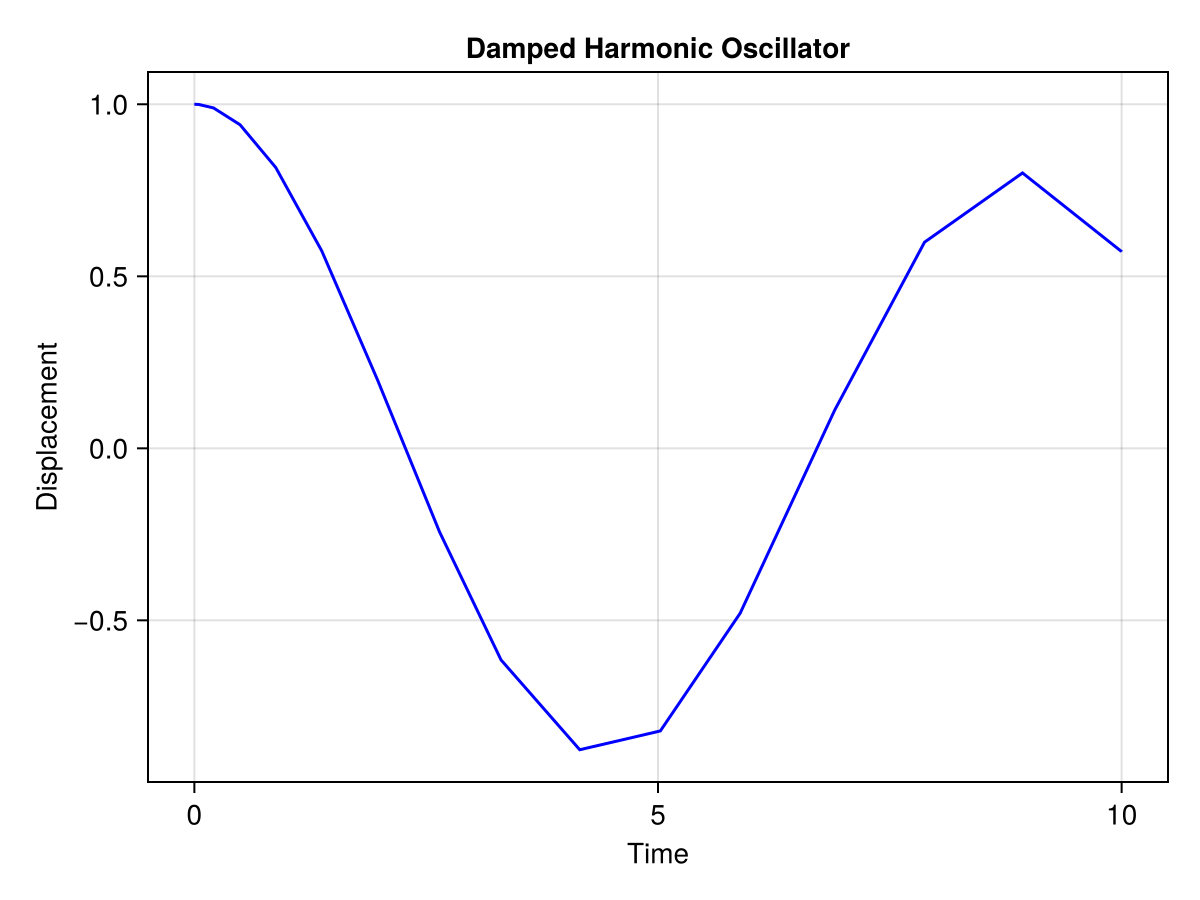

In [3]:
parameters = [0.1, 2.0, 1.0]  # μ, m, k
initial_conditions = [1.0, 0.0]  # x₀, v₀

tspan = (0.0, 10.0)

prob = ODEProblem(damped_harmonic_oscillator!, initial_conditions, tspan, parameters)
sol = solve(prob, Tsit5())

figure_dho = let f = Figure()
    ax = Axis(f[1, 1], xlabel = "Time", ylabel = "Displacement", title = "Damped Harmonic Oscillator")
    lines!(ax, sol.t, sol[1, :], color = :blue)
    f
end